# Primera Entrega: Obtención de Insights a partir de Visualizaciones

**Autor:** Vicente Tejos Medel

**Dataset:** Mercado de Arriendos (Portal Inmobiliario - RM)

**Fuente de Datos:** [Propiedades Alquiler PortalInmobiliario (Kaggle)](https://www.kaggle.com/datasets/edwight/propiedades-alquiler-portalinmobiliario)

---

## 1. Abstracto, Motivación y Audiencia
* **Motivación:** El mercado inmobiliario de arriendos en Chile presenta una alta volatilidad. Factores como la ubicación, el metraje y las amenidades (estacionamiento, bodega) generan fluctuaciones de precio que no siempre son transparentes. El análisis de estos datos busca decodificar qué variables impactan realmente en el valor final, permitiendo detectar sobreprecios u oportunidades de mercado.


* **Audiencia:** Este documento está dirigido a **inversionistas inmobiliarios** que buscan maximizar la rentabilidad de sus propiedades, y a **futuros arrendatarios** que necesitan evidencia basada en datos para optimizar su presupuesto.


## 2. Preguntas / Hipótesis que se buscan responder

1. **Hipótesis de Ubicación:** ¿Cómo varía el precio promedio de arriendo según la comuna y cuáles son los sectores más exclusivos?


2. **Hipótesis de Espacio:** ¿Existe una relación proporcional entre los metros cuadrados útiles de un departamento y su precio final de arriendo?


3. **Hipótesis de Costos Ocultos:** ¿Qué proporción del costo total mensual representan los gastos comunes según el tamaño del departamento?

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, Markdown # <-- ¡Esta es la magia!

sns.set_theme(style="whitegrid")

# Carga de los datos crudos locales
df = pd.read_csv('clean_alquiler_02_11_2023cc.csv')

# Imprimir resultado en Markdown
display(Markdown(f"""
### 📊 Metadata Inicial
* **Total de registros (filas):** `{df.shape[0]}`
* **Total de variables (columnas):** `{df.shape[1]}`
"""))


### 📊 Metadata Inicial
* **Total de registros (filas):** `1944`
* **Total de variables (columnas):** `30`


## 3. Limpieza y Transformación de Datos (Data Wrangling)
A partir de la exploración inicial (`df.info()`), se detectaron columnas vacías (como `orientacion`), valores nulos en amenidades (estacionamientos) y *outliers* de metraje producto de errores de digitación en el portal inmobiliario. Procedemos a limpiar el dataset para asegurar la validez estadística.

In [57]:
# Mostrar información general del DataFrame
df.info()

# Datos nulos por columna y porcentaje de nulos
nulos_por_columna = df.isnull().sum()
porcentaje_nulos = (nulos_por_columna / len(df)) * 100
nulos_df = pd.DataFrame({
    'Columna': nulos_por_columna.index,
    'Nulos': nulos_por_columna.values,
    'Porcentaje Nulos (%)': porcentaje_nulos.values
})
display(nulos_df)
# Estadísticas descriptivas para variables numéricas
estadisticas_descriptivas = df.describe()

display(estadisticas_descriptivas)
# Estadísticas descriptivas para variables categóricas
estadisticas_categoricas = df.describe(include=['object'])
display(estadisticas_categoricas)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1944 entries, 0 to 1943
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1944 non-null   int64  
 1   id                   1944 non-null   int64  
 2   link                 1944 non-null   object 
 3   titulo               1905 non-null   object 
 4   precio               1944 non-null   float64
 5   direction            1944 non-null   object 
 6   superficie_total     1944 non-null   float64
 7   superficie_util      1944 non-null   float64
 8   superficie_terraza   1944 non-null   float64
 9   ambientes            1944 non-null   int64  
 10  dormitorios          1944 non-null   int64  
 11  banos                1944 non-null   int64  
 12  estacionamientos     589 non-null    float64
 13  cant_max_habitantes  1944 non-null   int64  
 14  bodegas              493 non-null    float64
 15  gastos_comunes       1944 non-null   f

,Columna,Nulos,Porcentaje Nulos (%)
0,Unnamed: 0,0,0.000000
1,id,0,0.000000
2,link,0,0.000000
3,titulo,39,2.006173
4,precio,0,0.000000
5,direction,0,0.000000
6,superficie_total,0,0.000000
7,superficie_util,0,0.000000
8,superficie_terraza,0,0.000000
9,ambientes,0,0.000000


,Unnamed: 0,id,precio,superficie_total,superficie_util,superficie_terraza,ambientes,dormitorios,banos,estacionamientos,cant_max_habitantes,bodegas,gastos_comunes,orientacion,cantidad_pisos,departamentos_piso,numero_piso_unidad,latitude,longitude
count,1944.000000,1944.000000,1.944000e+03,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000,589.000000,1944.000000,493.000000,1.944000e+03,0.0,1944.000000,1944.000000,1944.000000,1554.000000,1554.000000
mean,971.500000,972.500000,4.327696e+05,576.556070,86.364198,44.668724,0.901749,1.365226,1.159465,1.244482,1.100309,1.008114,8.489080e+04,NaN,7.082819,4.761317,5.724280,-33.491947,-70.706898
std,561.328781,561.328781,3.382757e+05,1575.341313,634.131525,165.450825,1.219636,1.223523,1.089548,1.080749,2.778255,0.089800,8.732785e+04,NaN,9.595195,7.357612,52.714363,0.743529,0.329293
min,0.000000,1.000000,6.000000e+00,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000e+00,NaN,0.000000,0.000000,0.000000,-41.484889,-73.148928
25%,485.750000,486.750000,3.000000e+05,0.000000,35.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,5.000000e+04,NaN,0.000000,0.000000,0.000000,-33.478287,-70.679062
50%,971.500000,972.500000,3.823640e+05,45.000000,46.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,7.000000e+04,NaN,0.000000,0.000000,0.000000,-33.451164,-70.649344
75%,1457.250000,1458.250000,4.900000e+05,84.250000,64.000000,3.250000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,9.225000e+04,NaN,15.000000,10.000000,6.000000,-33.432073,-70.608225
max,1943.000000,1944.000000,4.500000e+06,20689.000000,25101.000000,3052.000000,7.000000,27.000000,27.000000,25.000000,100.000000,2.000000,1.500000e+06,NaN,38.000000,72.000000,1807.000000,-18.493011,-70.282783


,link,titulo,direction,tipo_departamento,codigo,fecha,published_time,comuna,published,divisa,region
count,1944,1905,1944,923,1157,1944,1944,1869,1944,1944,1869
unique,1944,1755,1354,8,1102,1,200,50,1877,3,13
top,https://www.portalinmobiliario.com/mlc-1320279...,departamento en arriendo de 3 dorm. en vitacura,"alcalde pedro alarcón 932, san miguel, chile, ...",departamento,0,2023-02-11 00:00:00.000000,corredora con identidad verificada,Santiago,2023-02-12 17:56:38.678309,pesos,Rm (metropolitana)
freq,1,6,24,485,47,1944,448,480,2,1694,1761


In [58]:
# 1. Eliminar columnas irrelevantes y 100% nulas ('orientacion')
cols_to_drop = ['Unnamed: 0', 'id', 'link', 'titulo', 'direction', 'codigo', 'published_time', 'fecha', 'orientacion']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Imputación de Valores Nulos (NaN)
# Asumimos que la ausencia de datos significa que NO posee estos extras (0)
df_clean['estacionamientos'] = df_clean['estacionamientos'].fillna(0)
df_clean['bodegas'] = df_clean['bodegas'].fillna(0)
df_clean['superficie_terraza'] = df_clean['superficie_terraza'].fillna(0)

# 3. Limpieza de Filas Incompletas Críticas
# Eliminamos registros que no tienen información de 'comuna' (son 75 filas)
df_clean = df_clean.dropna(subset=['comuna'])

# 4. Manejo de Outliers (Valores atípicos)
# Filtramos por superficie_util para no perder datos vitales
df_clean = df_clean[df_clean['superficie_util'].notna()]
df_clean = df_clean[(df_clean['superficie_util'] > 15) & (df_clean['superficie_util'] < 400)]

# Filtramos propiedades con precios absurdamente bajos (error de tipeo de los corredores)
df_clean = df_clean[df_clean['precio'] > 50000]

# Cálculos para el reporte interactivo
filas_iniciales = df.shape[0]
filas_finales = df_clean.shape[0]
filas_eliminadas = filas_iniciales - filas_finales
porcentaje_eliminado = (filas_eliminadas / filas_iniciales) * 100

# Imprimir resultado con formato Markdown
display(Markdown(f"""
### ✨ Metadata Post-Limpieza
* **Filas útiles para análisis final:** `{filas_finales}`
* **Registros descartados (Outliers/Nulos):** `{filas_eliminadas}` (*{porcentaje_eliminado:.1f}%* del dataset original)

> *Nota: Este proceso asegura la validez estadística para el Análisis Exploratorio (EDA), eliminando errores de digitación del portal y conservando una muestra robusta.*
"""))


### ✨ Metadata Post-Limpieza
* **Filas útiles para análisis final:** `1635`
* **Registros descartados (Outliers/Nulos):** `309` (*15.9%* del dataset original)

> *Nota: Este proceso asegura la validez estadística para el Análisis Exploratorio (EDA), eliminando errores de digitación del portal y conservando una muestra robusta.*


## 4. Análisis Exploratorio de Datos (EDA) y Visualizaciones Ejecutivas

### Visualización 1: El factor Ubicación (Polarización del Mercado)
Responderemos a la primera hipótesis analizando el Top 10 de las comunas con mayor precio promedio en nuestro dataset limpio.

C:\Users\vtejo\AppData\Local\Temp\ipykernel_22068\466514174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_comunas.values, y=top_comunas.index, palette='viridis')


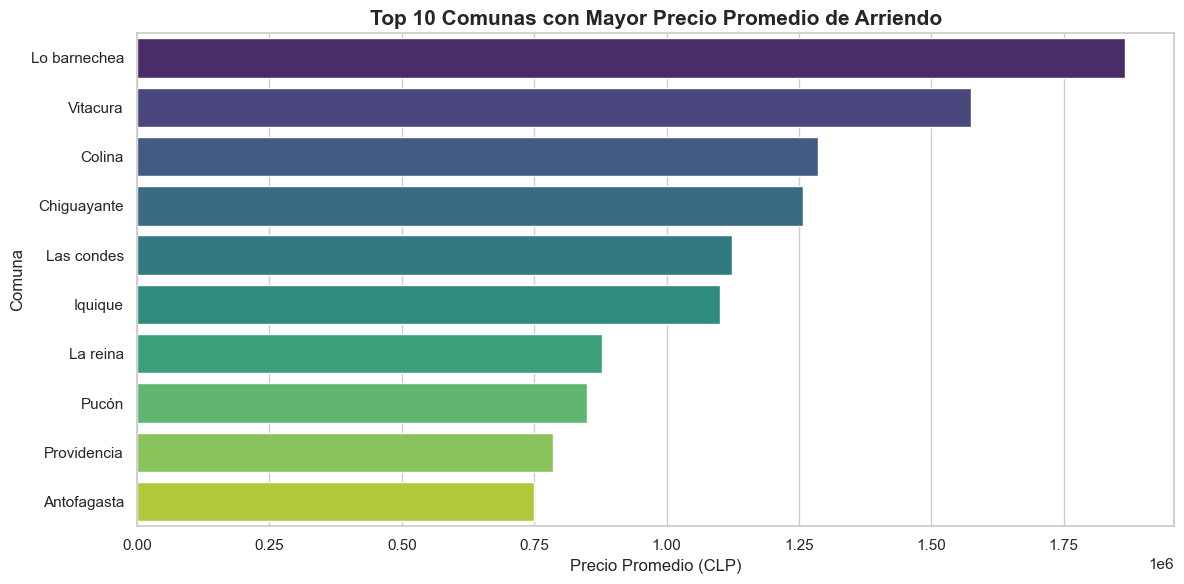

In [59]:
# Agrupar por comuna y calcular el precio promedio
top_comunas = df_clean.groupby('comuna')['precio'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_comunas.values, y=top_comunas.index, palette='viridis')
plt.title('Top 10 Comunas con Mayor Precio Promedio de Arriendo', fontsize=15, fontweight='bold')
plt.xlabel('Precio Promedio (CLP)', fontsize=12)
plt.ylabel('Comuna', fontsize=12)
plt.tight_layout()

# Guardar imagen para la presentación
plt.savefig('viz_1_ubicacion.png', dpi=300)
plt.show()

### Visualización 2: El valor del Espacio y el "Premium" de Amenidades
Crucemos la superficie útil con el precio, pero agreguemos una capa adicional: diferenciar mediante color aquellas propiedades que cuentan con al menos 1 estacionamiento.

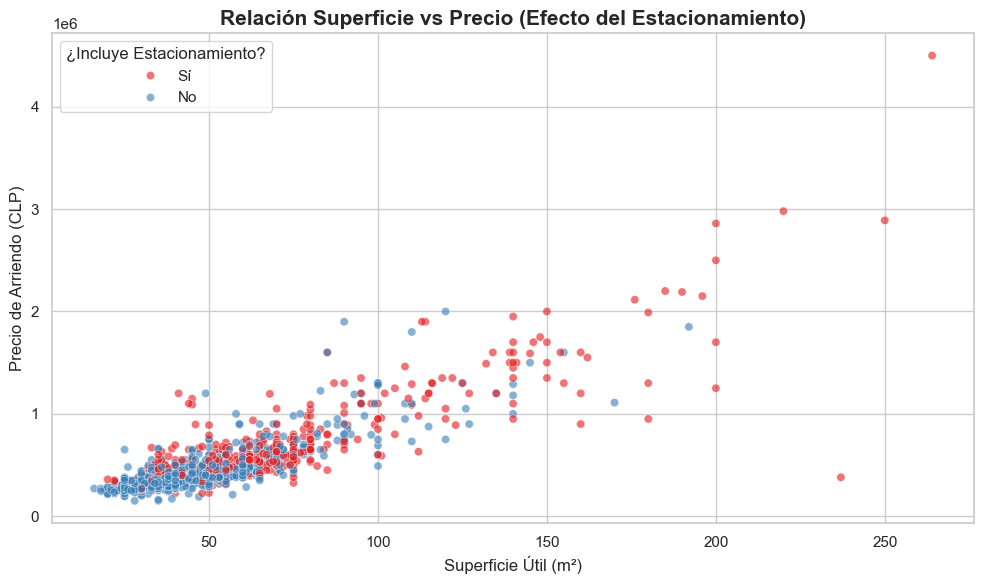

In [60]:
# Creamos una variable binaria para hacer el gráfico más limpio (Tiene o No Tiene Estacionamiento)
df_clean['tiene_estacionamiento'] = df_clean['estacionamientos'].apply(lambda x: 'Sí' if x > 0 else 'No')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='superficie_util', y='precio', hue='tiene_estacionamiento', palette='Set1', alpha=0.6)
plt.title('Relación Superficie vs Precio (Efecto del Estacionamiento)', fontsize=15, fontweight='bold')
plt.xlabel('Superficie Útil (m²)', fontsize=12)
plt.ylabel('Precio de Arriendo (CLP)', fontsize=12)
plt.legend(title='¿Incluye Estacionamiento?')
plt.tight_layout()

# Guardar imagen para la presentación
plt.savefig('viz_2_superficie.png', dpi=300)
plt.show()

### Visualización 3: Los Costos Ocultos (Gastos Comunes)
Para entender la carga real sobre el arrendatario, compararemos el precio base del arriendo con los gastos comunes, segmentado por el tamaño típico del departamento (1, 2 o 3 dormitorios).

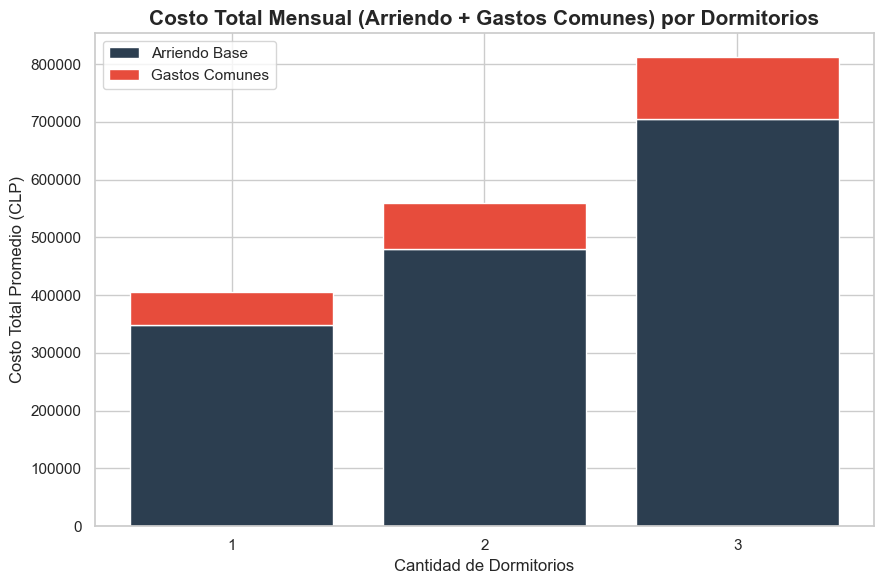

In [61]:
# Filtramos para ver solo departamentos de 1 a 3 dormitorios (el grueso del mercado)
df_dorm = df_clean[df_clean['dormitorios'].isin([1.0, 2.0, 3.0])].copy()

# Agrupamos los promedios
promedios_costos = df_dorm.groupby('dormitorios')[['precio', 'gastos_comunes']].mean().reset_index()

plt.figure(figsize=(9, 6))

# Gráfico de barras apiladas
plt.bar(promedios_costos['dormitorios'], promedios_costos['precio'], color='#2c3e50', label='Arriendo Base')
plt.bar(promedios_costos['dormitorios'], promedios_costos['gastos_comunes'], bottom=promedios_costos['precio'], color='#e74c3c', label='Gastos Comunes')

plt.title('Costo Total Mensual (Arriendo + Gastos Comunes) por Dormitorios', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad de Dormitorios', fontsize=12)
plt.ylabel('Costo Total Promedio (CLP)', fontsize=12)
plt.xticks([1, 2, 3])
plt.legend()
plt.tight_layout()

# Guardar imagen para la presentación
plt.savefig('viz_3_costos_ocultos.png', dpi=300)
plt.show()

## 5. Insights y Conclusiones de Negocio

A partir del Análisis Exploratorio de Datos (EDA) y las visualizaciones generadas, hemos consolidado las respuestas a nuestras hipótesis iniciales:

**1. El peso de la Ubicación (Polarización del Mercado):** El mercado está fuertemente polarizado por el sector geográfico. El **Sector Oriente (Vitacura y Las Condes)** domina la cúspide de precios, promediando sobre 1.2 millones de CLP, lo que representa más del doble del valor promedio de comunas residenciales clásicas como Ñuñoa o Macul. Destaca también la presencia de Viña del Mar y Valparaíso en el top, indicando un mercado de arriendos interregional altamente competitivo con la capital.

**2. El "Premium" del Estacionamiento sobre el Metraje:** Se confirma la tendencia al alza del precio a medida que aumentan los metros cuadrados, pero el hallazgo principal es el **efecto diferenciador del estacionamiento**. La dispersión de datos muestra que las propiedades con estacionamiento se posicionan sistemáticamente por encima en precio a igual metraje. Esto indica que un estacionamiento no es un simple "extra", sino que genera un salto estructural en el valor base del inmueble.

**3. El impacto regresivo de los Costos Ocultos:** Los gastos comunes representan un costo estructural significativo que castiga, en proporción, a los formatos más pequeños. En los departamentos de **1 dormitorio**, los gastos comunes añaden una carga base ineludible sobre el valor del arriendo. Esto demuestra que evaluar propiedades basándose únicamente en el "precio de lista" genera una visión sesgada del costo real de vida para el arrendatario y de la rentabilidad neta para el inversionista.